<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercicesSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=854ecd2ea31a748cf6ce090f9d6459024860d359bc9e4c962e3a3adcdda56ca5
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from ISLP.svm import plot as plot_svm
from ISLP import confusion_table

roc_curve = RocCurveDisplay.from_estimator


# 1 This problem involves hyperplanes in two dimensions

## (a) Sketch the hyperplane 1 + 3X1 − X2 = 0. Indicate the set of points for which 1 + 3X1 − X2 > 0, as well as the set of points for which 1 + 3X1 − X2 < 0.

In [ ]:
range1 = np.linspace(-5, 5, 100)
range2= np.linspace(-2, 2, 100)

xx, yy = np.meshgrid(range1, range2)
x_grid = np.c_[xx.ravel(), yy.ravel()]

betas = np.array([3, -1])
b0 = 1

z = np.dot(x_grid, betas) + b0
z = z.reshape(xx.shape)

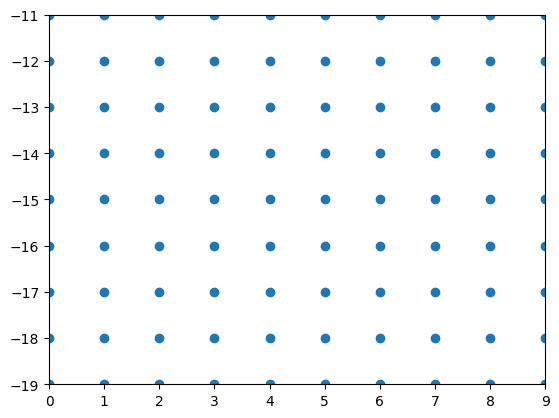

In [ ]:
r1 = np.arange(10)
r2 = np.arange(-11, -20, -1)

mesh = np.meshgrid(r1, r2)
grid= np.c_[mesh[0].ravel(), mesh[1].ravel()]
val_z = np.dot(grid, betas) + b0
val_z = val_z.reshape(mesh[0].shape)
plt.contour(mesh[0], mesh[1], val_z, levels=[0]);
plt.scatter(grid[:, 0], grid[:, 1])

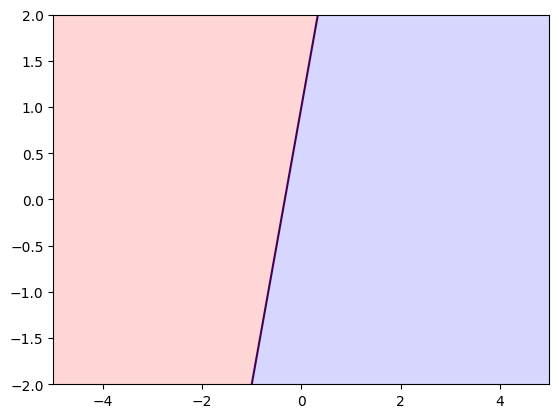

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)
plt.contour(xx, yy, z, levels=[0])

plt.show()

## (b) On the same plot, sketch the hyperplane −2 + X1 + 2X2 = 0. Indicate the set of points for which −2 + X1 + 2X2 > 0, as well as the set of points for which −2 + X1 + 2X2 < 0

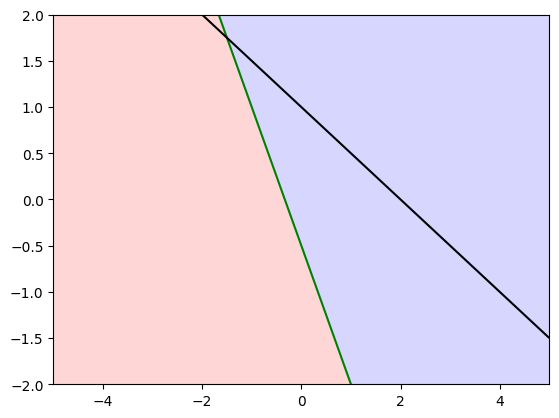

In [ ]:
new_betas = np.array([1, 2])
new_b0 = -2

new_z = np.dot(x_grid, new_betas) + new_b0
new_z = new_z.reshape(xx.shape)

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)

plt.contour(xx, yy, z, levels=[0], colors="green")
plt.contour(xx, yy, new_z, levels=[0], colors="black")


plt.show()

# 2.  We have seen that in p = 2 dimensions, a linear decision boundary takes  the form β0+β1X1+β2X2 = 0. We now investigate a non-linear decision boundary

## (a) Sketch the curve (1 + X1)^2 + (2 − X2)^2 = 4.

In [ ]:
# definamos el grid de vectores
x1 = np.linspace(-10, 10, 1000)
x2 = np.linspace(-10, 10, 1000)

xx, yy = np.meshgrid(x1, x2)
grid = np.c_[xx.ravel(), yy.ravel()]

z = (1 + grid[:, 0])**2 + (2 - grid[:, 1])**2 - 4
z = z.reshape(xx.shape)


## (b) On your sketch, indicate the set of points for which
 (1 + X1)2 + (2 − X2)2 > 4,
as well as the set of points for which
(1 + X1)2 + (2 − X2)2 ≤ 4.

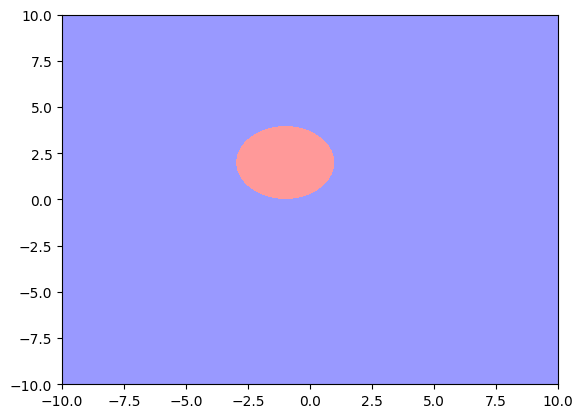

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])

## (c) Suppose that a classifier assigns an observation to the blue class if (1 + X1)2 + (2 − X2)2 > 4 and to the red class otherwise. To what class is the observation (0, 0) classified? (−1, 1)? (2, 2)? (3, 8)?

In [ ]:
obs = np.array([[0,0], [-1, 1], [2, 2], [3, 8]])
obs

array([[ 0,  0],
       [-1,  1],
       [ 2,  2],
       [ 3,  8]])

In [ ]:
zz = (1 + obs[:, 0]) ** 2 + (2 - obs[:, 1]) ** 2
np.where(zz > 4, "blue", "red")

array(['blue', 'red', 'blue', 'blue'], dtype='<U4')

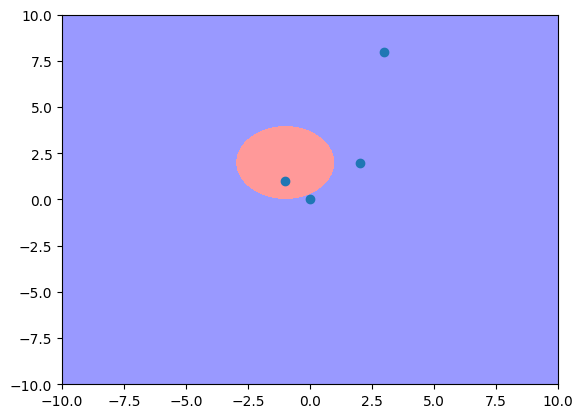

In [ ]:

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])
plt.scatter(obs[:, 0], obs[:, 1])

## (d) Argue that while the decision boundary in (c) is not linear in terms of X1 and X2, it is linear in terms of X1, X1^2, X2, and X2^2.

Esto es debido a que si expandimos la decision boundary que es no lineal, podemos apreciar que todos forman un hiperplano de forma lineal.

# 3. Here we explore the maximal margin classifier on a toy data set.


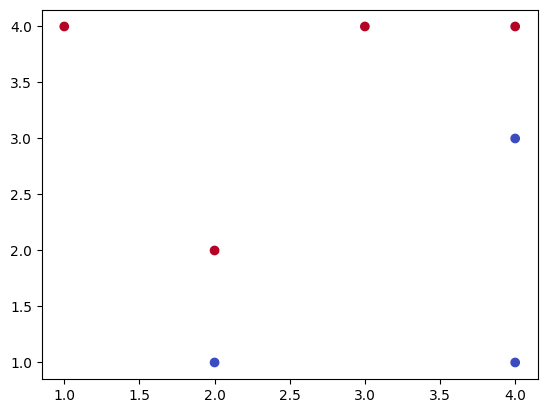

In [ ]:
obs = np.array([[3, 4],
                [2, 2],
                [4,4],
                [1, 4],
                [2,1],
                [4,3],
                [4,1]])
yy = [1,1,1,1,0,0,0]
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)

## (b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane (of the form (9.1))

In [ ]:
pendiente = (3.5 - 1.5) / (4 - 2)
pendiente

1.0

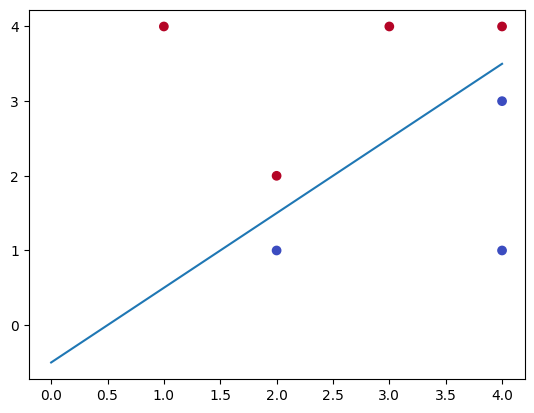

In [ ]:
x = np.arange(0, 5)
y = pendiente * x - 0.5
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)

Entonces la ecuacion del hiperplano seria:
$$-.5 + X_1 - X_2=0$$

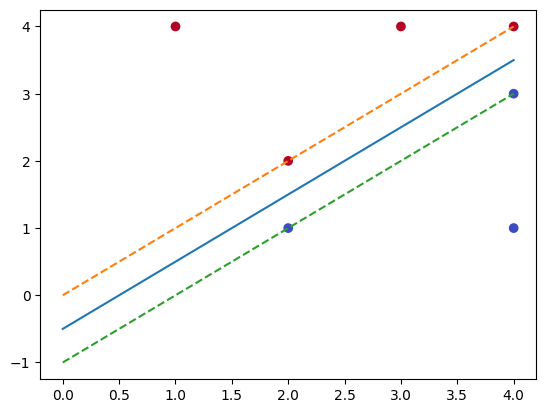

In [ ]:

plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)
plt.plot(x, y + .5,  linestyle="--")
plt.plot(x, y -.5, linestyle="--")

# 4

Generate a simulated two-class data set with 100 observations and
two features in which there is a visible but non-linear separation be-
tween the two classes. Show that in this setting, a support vector
machine with a polynomial kernel (with degree greater than 1) or a
radial kernel will outperform a support vector classifier on the train-
ing data. Which technique performs best on the test data? Make
plots and report training and test error rates in order to back up
your assertions.

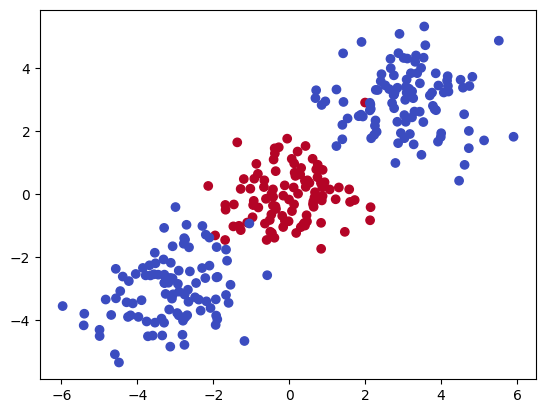

In [45]:
rng = np.random.default_rng(seed=42)

data1 = rng.normal(size=(100, 2))
data2 = rng.normal(loc=3, size=(100, 2))
data3 = rng.normal(loc=-3, size=(100, 2))

data1= np.hstack((np.ones((data1.shape[0], 1)), data1))
data2 = np.hstack((np.zeros((data2.shape[0], 1)), data2))
data3 = np.hstack((np.zeros((data3.shape[0], 1)), data3))

data = np.vstack((data1, data2, data3))
plt.scatter(data[:, 1], data[:, 2], c=data[:, 0], cmap=plt.cm.coolwarm)

In [46]:
data1

array([[ 1.        ,  0.30471708, -1.03998411],
       [ 1.        ,  0.7504512 ,  0.94056472],
       [ 1.        , -1.95103519, -1.30217951],
       [ 1.        ,  0.1278404 , -0.31624259],
       [ 1.        , -0.01680116, -0.85304393],
       [ 1.        ,  0.87939797,  0.77779194],
       [ 1.        ,  0.0660307 ,  1.12724121],
       [ 1.        ,  0.46750934, -0.85929246],
       [ 1.        ,  0.36875078, -0.9588826 ],
       [ 1.        ,  0.8784503 , -0.04992591],
       [ 1.        , -0.18486236, -0.68092954],
       [ 1.        ,  1.22254134, -0.15452948],
       [ 1.        , -0.42832782, -0.35213355],
       [ 1.        ,  0.53230919,  0.36544406],
       [ 1.        ,  0.41273261,  0.430821  ],
       [ 1.        ,  2.1416476 , -0.40641502],
       [ 1.        , -0.51224273, -0.81377273],
       [ 1.        ,  0.61597942,  1.12897229],
       [ 1.        , -0.11394746, -0.84015648],
       [ 1.        , -0.82448122,  0.65059279],
       [ 1.        ,  0.74325417,  0.543

Ya hemos generado el dataset sintetico, en donde se peude apreciar claramente la division no lineal de los datos.


## Train and test validation set

In [ ]:
X_train, X_test, y_train, y_test = skm.train_test_split(data[:, 1:],
                                                        data[:, 0],
                                                        test_size=.3,
                                                        random_state=42)

## Support Vector Classifier

In [ ]:
svc_linear = SVC(C=0.0001, kernel="linear").fit(X_train, y_train)

y_hat_linear = svc_linear.predict(X_train)
confusion_table(y_train, y_hat_linear)

Truth,0.0,1.0
Predicted,,
0.0,145,0
1.0,65,0


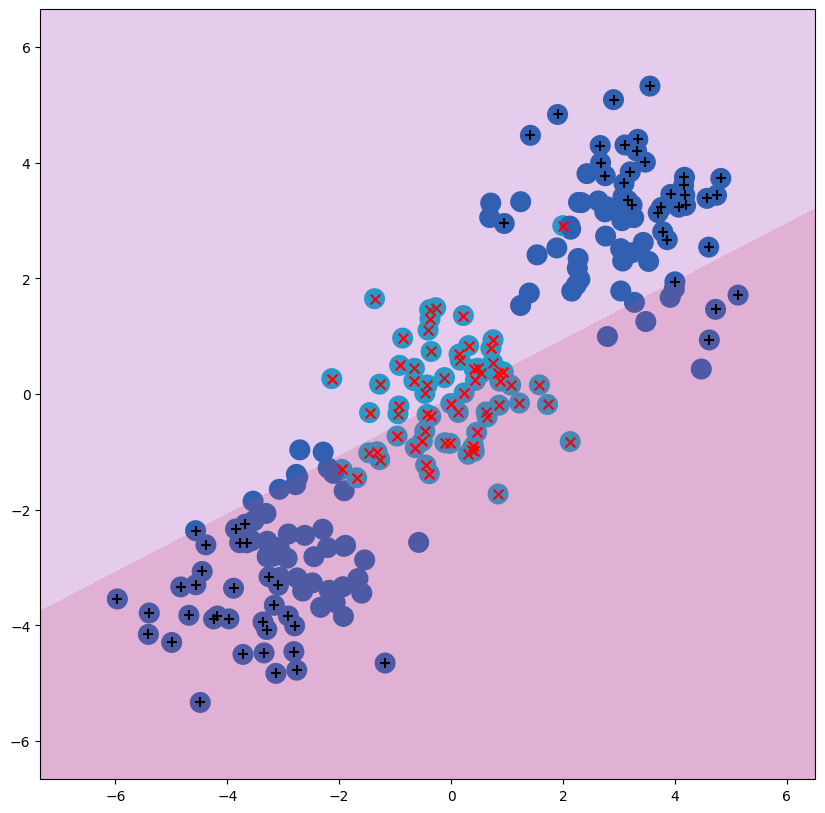

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_linear,
         ax=ax)

podemos apreciar que no se puede capturar la relacion de los datos porque es no linear

## Support Vector Machine (Kernel poly)

In [ ]:
svc_poly = SVC(C=1, kernel="poly", degree=4).fit(X_train, y_train)
y_hat_poly = svc_poly.predict(X_test)
confusion_table(y_test, y_hat_poly)

Truth,0.0,1.0
Predicted,,
0.0,50,5
1.0,0,35


In [ ]:
svc_poly.score(X_test, y_test), 35 / (35 + 18)

(0.9444444444444444, 0.660377358490566)

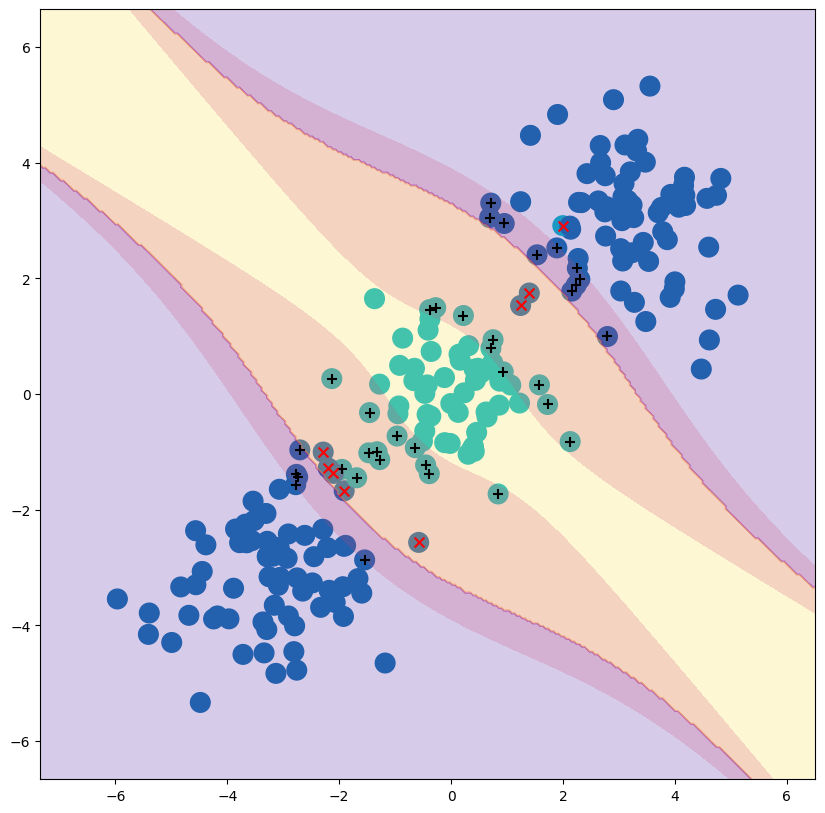

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_poly,
         ax=ax)


Podemos apreciar que existen configuracioens del kernel poly os cuales lograncapturar hasta cierto punto la no linearidad.

## Support Vector Machine (kernel rbf)

In [ ]:
svc_rbf = SVC(C = 1, kernel="rbf").fit(X_train, y_train)
y_hat_rbf = svc_rbf.predict(X_test)
confusion_table(y_test, y_hat_rbf)

Truth,0.0,1.0
Predicted,,
0.0,54,1
1.0,0,35


In [ ]:
svc_rbf.score(X_test, y_test), 35 / (35 + 1)

(0.9888888888888889, 0.9722222222222222)

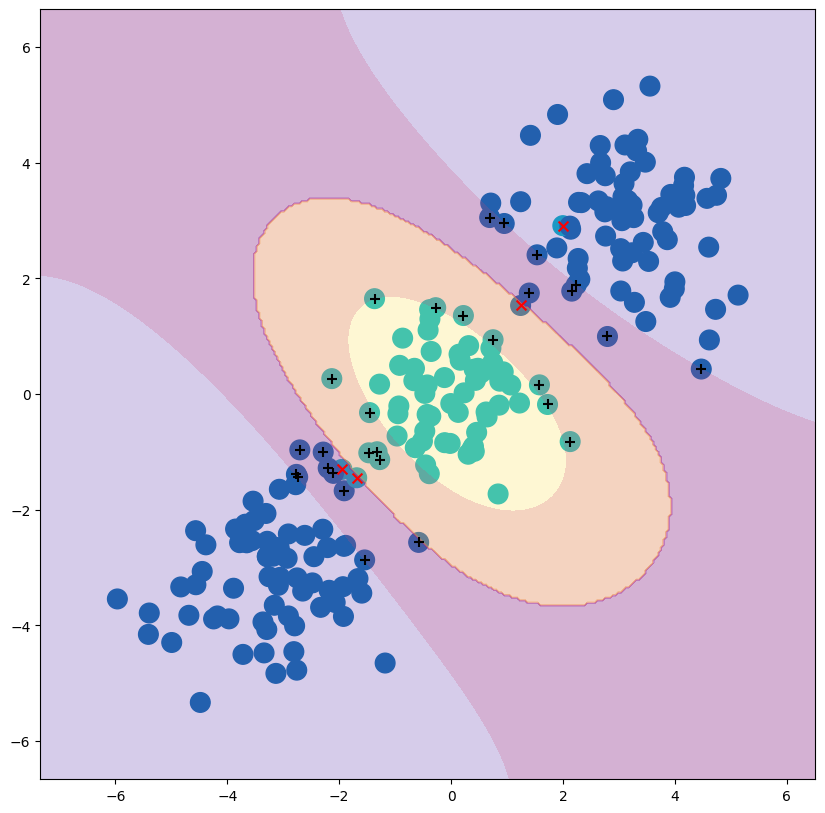

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_rbf,
         ax=ax)

Podemos apreciar que este modelo es el mejor en clasificar segun los datos de entreanmiento./

In [ ]:
print(f"Training error for linear: {1 - svc_linear.score(X_train, y_train)}")
print(f"Training error for poly: {1 - svc_poly.score(X_train, y_train)}")
print(f"Training error for rbf: {1 - svc_rbf.score(X_train, y_train)}")


Training error for linear: 0.30952380952380953
Training error for poly: 0.03809523809523807
Training error for rbf: 0.01904761904761909


In [ ]:
print(f"Test error for linear: {1 - svc_linear.score(X_test, y_test)}")
print(f"Test error for poly: {1 - svc_poly.score(X_test, y_test)}")
print(f"Test error for rbf: {1 - svc_rbf.score(X_test, y_test)}")


Test error for linear: 0.38888888888888884
Test error for poly: 0.05555555555555558
Test error for rbf: 0.011111111111111072


# 5

We have seen that we can fit an SVM with a non-linear kernel in order
to perform classification using a non-linear decision boundary. We will
now see that we can also obtain a non-linear decision boundary by
performing logistic regression using non-linear transformations of the
features.

(a) Generate a data set with n = 500 and p = 2, such that the obser-
vations belong to two classes with a quadratic decision boundary
between them. For instance, you can do this as follows:

In [ ]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0

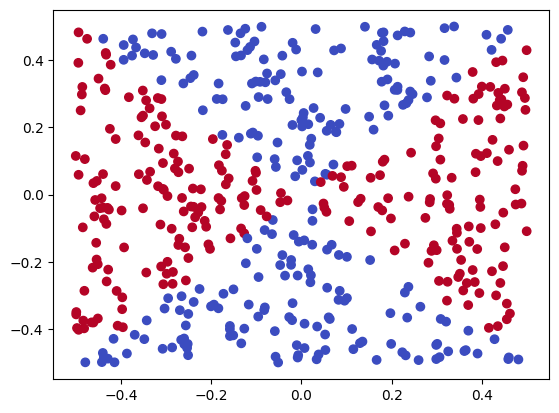

In [ ]:
plt.scatter(x1, x2, c=y, cmap=plt.cm.coolwarm)

(c) Fit a logistic regression model to the data, using X1 and X2 as
predictors

In [ ]:
logit = skl.LogisticRegression().fit(np.c_[x1, x2], y)


(d) Apply this model to the training data in order to obtain a pre-
dicted class label for each training observation. Plot the ob-
servations, colored according to the predicted class labels. The
decision boundary should be linear.

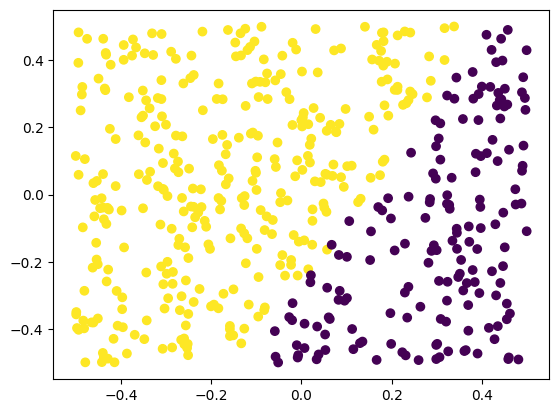

In [ ]:
y_hat = logit.predict(np.c_[x1, x2])
plt.scatter(x1, x2, c=y_hat)

(e) Now fit a logistic regression model to the data using non-linear
functions of X1 and X2 as predictors (e.g. X2
1, X1×X2, log(X2),
and so forth).

In [ ]:
x1_2 = x1 * x1
x1_3 = np.power(x1, 3)
x2_2 = x2 * x2
x2_3 = np.power(x2, 3)
logit_non_linear = skl.LogisticRegression().fit(np.c_[x1, x2, x1_2, x1_3, x2_2, x2_3], y)
y_hat = logit_non_linear.predict(np.c_[x1, x2, x1_2, x1_3, x2_2, x2_3])

In [ ]:
confusion_table(y_hat, y)

Truth,False,True
Predicted,,
False,226,2
True,21,251


(f) Apply this model to the training data in order to obtain a pre-
dicted class label for each training observation. Plot the ob-
servations, colored according to the predicted class labels. The
decision boundary should be obviously non-linear. If it is not,
then repeat (a)–(e) until you come up with an example in which
the predicted class labels are obviously non-linear.

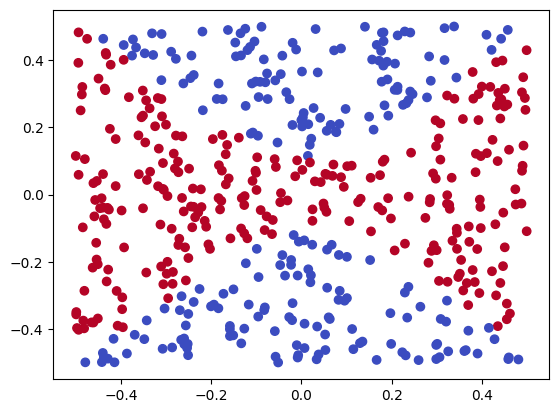

In [ ]:
plt.scatter(x1, x2, c=y_hat, cmap=plt.cm.coolwarm)

(g) Fit a support vector classifier to the data with X1 and X2 as
predictors. Obtain a class prediction for each training observa-
tion. Plot the observations, colored according to the predicted
class labels.

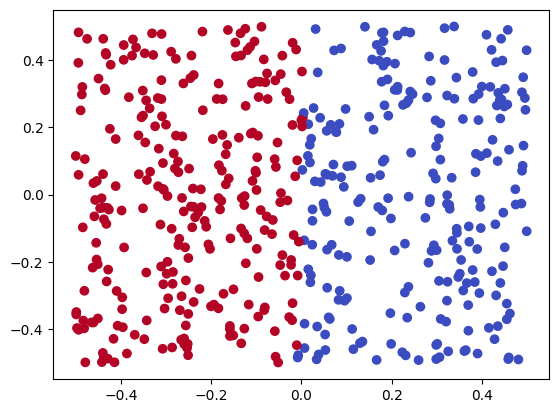

In [ ]:
svc = SVC(C= 10, kernel="linear").fit(np.c_[x1, x2], y)
y_hat = svc.predict(np.c_[x1, x2])
plt.scatter(x1, x2, c=y_hat, cmap=plt.cm.coolwarm)

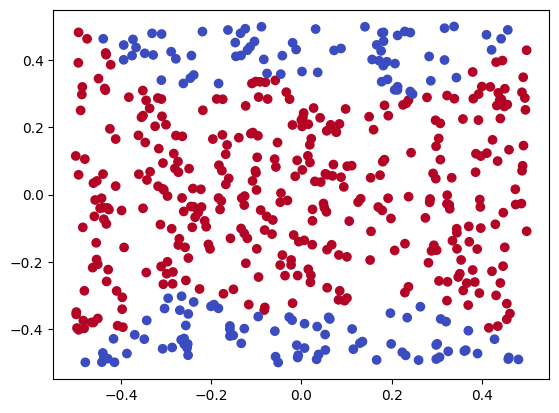

In [ ]:
svc = SVC(C= 10, kernel="poly", degree=20).fit(np.c_[x1, x2], y)
y_hat = svc.predict(np.c_[x1, x2])
plt.scatter(x1, x2, c=y_hat, cmap=plt.cm.coolwarm)

(h) Fit a SVM using a non-linear kernel to the data. Obtain a class
prediction for each training observation. Plot the observations,
colored according to the predicted class labels

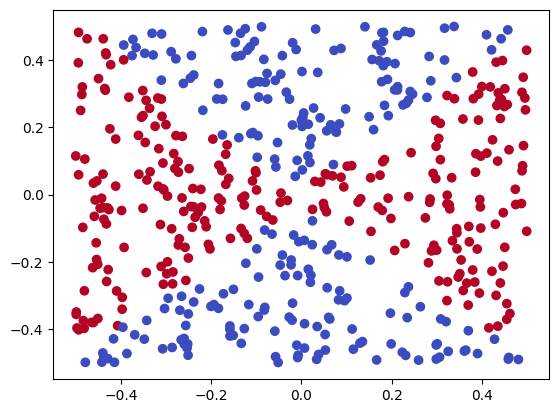

In [ ]:
svc_rbf = SVC(C=10, kernel="rbf").fit(np.c_[x1, x2], y)
y_hat = svc_rbf.predict(np.c_[x1, x2])
plt.scatter(x1, x2, c=y_hat, cmap=plt.cm.coolwarm)

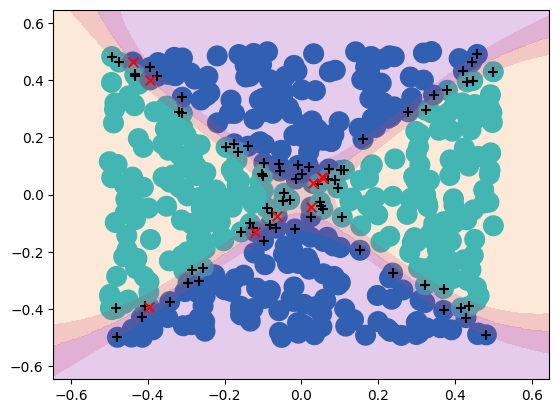

In [37]:
plot_svm(np.c_[x1, x2], y, svc_rbf)

(i) Comment on your results

Podedmos apreciar que modelos de SVM linear o poly estan muy lejos de capturar la escencia de elos datos, sin embargo el uso de la logistic regression con un espacio de features ampliaddo para la no linealidad junto con el kernel radial en el caso de SVM logran capturar hasta cierto punto la forma de los datos.

# 6.
At the end of Section 9.6.1, it is claimed that in the case of data that is
just barely linearly separable, a support vector classifier with a small
value of C that misclassifies a couple of training observations may
perform better on test data than one with a huge value of C that does
not misclassify any training observations. You will now investigate
this claim

(a) Generate two-class data with p = 2 in such a way that the classes
are just barely linearly separable

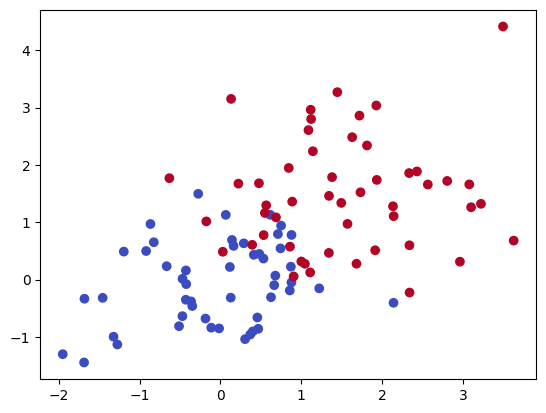

In [73]:
rng = np.random.default_rng(42)
X = rng.normal(size=(100, 2))
X[50:] += 1.5
y = np.array([0] * 50 + [1] * 50)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=20, random_state=42)

(b) Compute the cross-validation error rates for support vector
classifiers with a range of C values. How many training obser-
vations are misclassified for each value of C considered, and how
does this relate to the cross-validation errors obtained

In [74]:
kfold = skm.KFold(n_splits=5,
                  shuffle=True,
                  random_state=42)

params = {"C": [0.01, .1, 1, 2,4,5,10, 100, 500 ,100]}

grid = skm.GridSearchCV(SVC(kernel="linear"), params, cv=kfold, scoring="accuracy")
grid.fit(X, y)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(kernel='linear'),
             param_grid={'C': [0.01, 0.1, 1, 2, 4, 5, 10, 100, 500, 100]},
             scoring='accuracy')

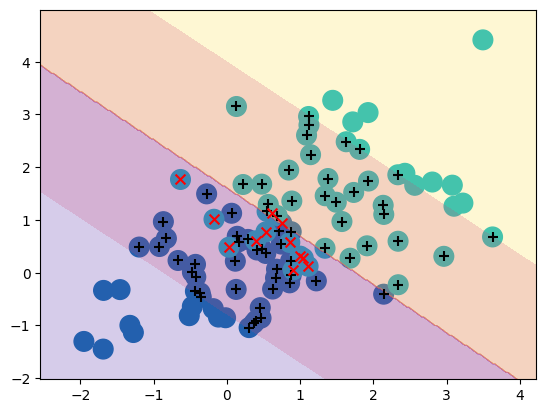

In [75]:
best_ = grid.best_estimator_
plot_svm(X, y, best_)


In [76]:
np.sum(best_.predict(X) != y)

np.int64(12)

In [83]:
1 -grid.cv_results_["mean_test_score"]

array([0.15, 0.15, 0.16, 0.17, 0.16, 0.16, 0.15, 0.16, 0.16, 0.16])

In [79]:
# hagamos un bucle
missed_train = {}
missed_test = {}

for c in params["C"]:
    svc = SVC(C=c, kernel="linear").fit(X_train, y_train)
    y_hat = svc.predict(X_train)
    missed_train[c] = np.sum(y_hat != y_train)
    missed_test[c] = np.sum(svc.predict(X_test) != y_test)


In [80]:
missed_test, missed_train

({0.01: np.int64(2),
  0.1: np.int64(2),
  1: np.int64(2),
  2: np.int64(2),
  4: np.int64(2),
  5: np.int64(2),
  10: np.int64(2),
  100: np.int64(2),
  500: np.int64(2)},
 {0.01: np.int64(12),
  0.1: np.int64(11),
  1: np.int64(13),
  2: np.int64(13),
  4: np.int64(12),
  5: np.int64(12),
  10: np.int64(12),
  100: np.int64(12),
  500: np.int64(12)})